<a href="https://colab.research.google.com/github/Rohith0750/Integrated-Farm-Mangement-System/blob/main/modelTrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os

# List contents of your Google Drive. You might need to navigate into specific folders.
# For example, to list contents of 'My Drive', use '/content/drive/MyDrive'
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Photos ', 'Photos press', 'Classroom', 'Rohith S D.gsite', 'Google Earth', 'adhar card (2).pdf', 'adhar card (1).pdf', 'adhar card.pdf', 'WhatsApp Image 2025-05-31 at 17.13 (1).31_9661cde5.jpg', 'WhatsApp Image 2025-05-31 at 17.13.31_9661cde5.jpg', 'AIFundamentals by cisco ibm.pdf', 'rohithsd_resume (1) (4).pdf', 'rohithsd_resume (1) (3).pdf', 'rohithsd_resume (1) (2).pdf', 'id card.pdf', 'rohithsd_resume (1) (1).pdf', 'rohithsd_resume (1).pdf', 'Poching Project.mp4', '20231CSE0750.pdf', 'Assignment.pdf', 'Screenshot 2025-07-29 211246.png', 'Advaced-to-do-list-main.zip', 'Building-a-To-Do-List-Application-with-HTML-CSS-JavaScript-and-GitHub.pptx', 'Screenshot 2025-08-02 141751.png', 'Screenshot 2025-08-02 141928.png', 'Screenshot 2025-08-02 142114.png', 'ibm project.pdf', 'IMG-20250815-WA0011.jpg', 'Student Testimonial.docx', 'Team vikasana ', 'Team Vikasana.pptx', 'Team Vikasana', 'SIH Winning project GitHub links.gsheet', 'SIH2025-IDEA-Presentation-Format (1).pdf

Once you've identified the path to your dataset (e.g., `/content/drive/MyDrive/my_dataset_folder/data.csv`), you can proceed to load it. The exact code for loading will depend on the type of your dataset (e.g., CSV, images, text files). For example, if it's a CSV file, you can use pandas:

```python
# Example for a CSV file
import pandas as pd
dataset_path = '/content/drive/MyDrive/my_dataset_folder/data.csv'
df = pd.read_csv(dataset_path)
display(df.head())
```

Or, if you have an image dataset, you would typically use libraries like `tensorflow.keras.utils.image_dataset_from_directory` or `torchvision.datasets.ImageFolder` after defining the base directory.

In [5]:
import os

# List the contents of the 'ml service datasets' directory
dataset_dir_path = '/content/drive/MyDrive/ml-service'

if os.path.exists(dataset_dir_path):
    print(f"Contents of '{dataset_dir_path}':")
    print(os.listdir(dataset_dir_path))
else:
    print(f"The directory '{dataset_dir_path}' does not exist. Please check the path.")

Contents of '/content/drive/MyDrive/ml-service':
['run.py', 'requirements.txt', '.gitignore', 'README.md', 'context.md', 'venv', 'datasets', 'training']


In [6]:
import os

# Construct the path to the 'datasets' directory
datasets_sub_dir_path = os.path.join(dataset_dir_path, 'datasets')

if os.path.exists(datasets_sub_dir_path):
    print(f"Contents of '{datasets_sub_dir_path}':")
    print(os.listdir(datasets_sub_dir_path))
else:
    print(f"The directory '{datasets_sub_dir_path}' does not exist. Please check the path.")

Contents of '/content/drive/MyDrive/ml-service/datasets':
['raw', 'tomato']


In [7]:
import os

DATASET_PATH = "/content/drive/MyDrive/ml-service/datasets/tomato"

print("Dataset exists:", os.path.exists(DATASET_PATH))
print("Contents:", os.listdir(DATASET_PATH))

Dataset exists: True
Contents: ['train', 'val', 'test']


In [8]:
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

tomato/
  train/
    Tomato_Tomato_mosaic_virus/
    Tomato_Tomato_YellowLeaf_Curl_Virus/
    Tomato_Early_blight/
    Tomato_Target_Spot/
    Tomato_Spider_mites_Two_spotted_spider_mite/
    Tomato_Septoria_leaf_spot/
    Tomato_Leaf_Mold/
    Tomato_healthy/
    Tomato_Late_blight/
    Tomato_Bacterial_spot/
  val/
    Tomato_Septoria_leaf_spot/
    Tomato_Tomato_mosaic_virus/
    Tomato_Leaf_Mold/
    Tomato_Tomato_YellowLeaf_Curl_Virus/
    Tomato_Spider_mites_Two_spotted_spider_mite/
    Tomato_Target_Spot/
    Tomato_healthy/
    Tomato_Early_blight/
    Tomato_Bacterial_spot/
    Tomato_Late_blight/
  test/
    Tomato_Tomato_mosaic_virus/
    Tomato_Tomato_YellowLeaf_Curl_Virus/
    Tomato_Target_Spot/
    Tomato_Spider_mites_Two_spotted_spider_mite/
    Tomato_Septoria_leaf_spot/
    Tomato_Late_blight/
    Tomato_Leaf_Mold/
    Tomato_Bacterial_spot/
    Tomato_Early_blight/
    Tomato_healthy/


In [9]:
from pathlib import Path

for split in ["train", "val", "test"]:
    split_path = Path(DATASET_PATH) / split

    if not split_path.exists():
        print(f"{split} folder not found")
        continue

    print(f"\n===== {split.upper()} =====")

    for class_dir in sorted(split_path.iterdir()):
        if class_dir.is_dir():
            count = len(list(class_dir.glob("*")))
            print(f"{class_dir.name:45} {count}")


===== TRAIN =====
Tomato_Bacterial_spot                         1490
Tomato_Early_blight                           700
Tomato_Late_blight                            1336
Tomato_Leaf_Mold                              666
Tomato_Septoria_leaf_spot                     1240
Tomato_Spider_mites_Two_spotted_spider_mite   1173
Tomato_Target_Spot                            983
Tomato_Tomato_YellowLeaf_Curl_Virus           2247
Tomato_Tomato_mosaic_virus                    261
Tomato_healthy                                1114

===== VAL =====
Tomato_Bacterial_spot                         425
Tomato_Early_blight                           200
Tomato_Late_blight                            382
Tomato_Leaf_Mold                              190
Tomato_Septoria_leaf_spot                     354
Tomato_Spider_mites_Two_spotted_spider_mite   335
Tomato_Target_Spot                            281
Tomato_Tomato_YellowLeaf_Curl_Virus           642
Tomato_Tomato_mosaic_virus                    75
Tomato_he

In [10]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [11]:
import os
import json
import copy
import time

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [12]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

DATASET_PATH = "/content/drive/MyDrive/ml-service/datasets/tomato"

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "val")
test_dir = os.path.join(DATASET_PATH, "test")

print(train_dir)
print(val_dir)
print(test_dir)

/content/drive/MyDrive/ml-service/datasets/tomato/train
/content/drive/MyDrive/ml-service/datasets/tomato/val
/content/drive/MyDrive/ml-service/datasets/tomato/test


After listing the contents, you should be able to identify the specific file or folder containing your training data. Once you have the exact path, you can then proceed to load it into your notebook using appropriate libraries (e.g., pandas for CSVs, image loading libraries for image datasets).

After inspecting the contents of `ml service datasets`, you can then choose the appropriate files or subdirectories to load for your training. If your dataset is within a specific subfolder, you might need to adjust the `dataset_dir_path` accordingly.

In [13]:
IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [14]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transforms
)

print("Number of classes:", len(train_dataset.classes))
print("Classes:")

for i, class_name in enumerate(train_dataset.classes):
    print(i, "->", class_name)

Number of classes: 10
Classes:
0 -> Tomato_Bacterial_spot
1 -> Tomato_Early_blight
2 -> Tomato_Late_blight
3 -> Tomato_Leaf_Mold
4 -> Tomato_Septoria_leaf_spot
5 -> Tomato_Spider_mites_Two_spotted_spider_mite
6 -> Tomato_Target_Spot
7 -> Tomato_Tomato_YellowLeaf_Curl_Virus
8 -> Tomato_Tomato_mosaic_virus
9 -> Tomato_healthy


In [15]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 11210
Validation: 3202
Test: 1601


In [16]:
import torch
import numpy as np

class_counts = np.bincount(train_dataset.targets)

class_weights = len(train_dataset) / (
    len(class_counts) * class_counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Class weights:")

for class_name, weight in zip(
    train_dataset.classes,
    class_weights
):
    print(f"{class_name:50} {weight:.4f}")

Class weights:
Tomato_Bacterial_spot                              0.7523
Tomato_Early_blight                                1.6014
Tomato_Late_blight                                 0.8391
Tomato_Leaf_Mold                                   1.6832
Tomato_Septoria_leaf_spot                          0.9040
Tomato_Spider_mites_Two_spotted_spider_mite        0.9557
Tomato_Target_Spot                                 1.1404
Tomato_Tomato_YellowLeaf_Curl_Virus                0.4989
Tomato_Tomato_mosaic_virus                         4.2950
Tomato_healthy                                     1.0063


In [17]:
# Step 8 — Load EfficientNet-B0

import torch
import torch.nn as nn
from torchvision import models

# Check device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Load pretrained EfficientNet-B0
weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(
    weights=weights
)

# Number of disease classes
num_classes = len(train_dataset.classes)

# Replace final classification layer
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

# Move model to GPU
model = model.to(device)

print("Model loaded successfully!")
print("Number of classes:", num_classes)
print("Classes:", train_dataset.classes)

Device: cuda
GPU: Tesla T4
Model loaded successfully!
Number of classes: 10
Classes: ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Target_Spot', 'Tomato_Tomato_YellowLeaf_Curl_Virus', 'Tomato_Tomato_mosaic_virus', 'Tomato_healthy']


In [18]:
import torch
import numpy as np

# Number of images in each class
class_counts = np.bincount(train_dataset.targets)

# Calculate balanced class weights
class_weights = len(train_dataset) / (
    len(class_counts) * class_counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Class weights:\n")

for class_name, count, weight in zip(
    train_dataset.classes,
    class_counts,
    class_weights
):
    print(
        f"{class_name:50} "
        f"Images: {count:4d} "
        f"Weight: {weight:.4f}"
    )

Class weights:

Tomato_Bacterial_spot                              Images: 1490 Weight: 0.7523
Tomato_Early_blight                                Images:  700 Weight: 1.6014
Tomato_Late_blight                                 Images: 1336 Weight: 0.8391
Tomato_Leaf_Mold                                   Images:  666 Weight: 1.6832
Tomato_Septoria_leaf_spot                          Images: 1240 Weight: 0.9040
Tomato_Spider_mites_Two_spotted_spider_mite        Images: 1173 Weight: 0.9557
Tomato_Target_Spot                                 Images:  983 Weight: 1.1404
Tomato_Tomato_YellowLeaf_Curl_Virus                Images: 2247 Weight: 0.4989
Tomato_Tomato_mosaic_virus                         Images:  261 Weight: 4.2950
Tomato_healthy                                     Images: 1114 Weight: 1.0063


In [19]:
import torch.optim as optim

# Move weights to GPU
class_weights = class_weights.to(device)

# Weighted classification loss
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

# Learning-rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2,
    factor=0.5
)

print("Loss, optimizer and scheduler ready!")

Loss, optimizer and scheduler ready!


In [20]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [21]:
def validate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [23]:
import time

NUM_EPOCHS = 10

best_val_accuracy = 0.0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "ml-service/best_tomato_disease_model.pth"
)

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # Training
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Validation
    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # Update learning rate
    scheduler.step(val_loss)

    # Save history
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    # Save best model
    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        status = " ⭐ BEST MODEL"
    else:
        status = ""

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Time: {elapsed:.1f}s | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}%"
        f"{status}"
    )

KeyboardInterrupt: 

In [24]:
!cp -r "/content/drive/MyDrive/ml-service/datasets/tomato" "/content/tomato"

In [26]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = "/content/tomato/train"
val_dir = "/content/tomato/val"
test_dir = "/content/tomato/test"

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transforms
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 11210
Val: 3202
Test: 1601


In [29]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully")

DataLoaders created successfully


In [27]:
import time

start = time.time()

images, labels = next(iter(train_loader))

print("Batch loaded successfully!")
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Time:", round(time.time() - start, 2), "seconds")

Batch loaded successfully!
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Time: 1.22 seconds


In [28]:
print(model)
print("Device:", device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [30]:
NUM_EPOCHS = 10

best_val_accuracy = 0.0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "ml-service/best_tomato_disease_model.pth"
)

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        status = " ⭐ BEST MODEL"
    else:
        status = ""

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Time: {elapsed:.1f}s | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}%"
        f"{status}"
    )

Epoch [1/10] Time: 86.5s | Train Loss: 0.0607 | Train Acc: 98.25% | Val Loss: 0.0341 | Val Acc: 98.88% ⭐ BEST MODEL
Epoch [2/10] Time: 80.4s | Train Loss: 0.0500 | Train Acc: 98.55% | Val Loss: 0.0250 | Val Acc: 99.28% ⭐ BEST MODEL
Epoch [3/10] Time: 81.7s | Train Loss: 0.0340 | Train Acc: 99.02% | Val Loss: 0.0191 | Val Acc: 99.47% ⭐ BEST MODEL
Epoch [4/10] Time: 81.0s | Train Loss: 0.0288 | Train Acc: 99.06% | Val Loss: 0.0137 | Val Acc: 99.63% ⭐ BEST MODEL
Epoch [5/10] Time: 80.7s | Train Loss: 0.0210 | Train Acc: 99.44% | Val Loss: 0.0114 | Val Acc: 99.66% ⭐ BEST MODEL
Epoch [6/10] Time: 81.6s | Train Loss: 0.0227 | Train Acc: 99.35% | Val Loss: 0.0151 | Val Acc: 99.63%
Epoch [7/10] Time: 79.9s | Train Loss: 0.0179 | Train Acc: 99.50% | Val Loss: 0.0122 | Val Acc: 99.75% ⭐ BEST MODEL
Epoch [8/10] Time: 82.8s | Train Loss: 0.0196 | Train Acc: 99.34% | Val Loss: 0.0148 | Val Acc: 99.59%
Epoch [9/10] Time: 81.8s | Train Loss: 0.0091 | Train Acc: 99.76% | Val Loss: 0.0076 | Val Acc: 99

In [31]:
MODEL_PATH = "/content/drive/MyDrive/ml-service/best_tomato_disease_model.pth"

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [32]:
test_loss, test_accuracy = validate(
    model,
    test_loader,
    criterion,
    device
)

print("====================================")
print("        TEST RESULTS")
print("====================================")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

        TEST RESULTS
Test Loss: 0.0027
Test Accuracy: 99.94%


In [33]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes,
        digits=4
    )
)

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot     1.0000    1.0000    1.0000       213
                        Tomato_Early_blight     1.0000    1.0000    1.0000       100
                         Tomato_Late_blight     1.0000    1.0000    1.0000       191
                           Tomato_Leaf_Mold     1.0000    1.0000    1.0000        96
                  Tomato_Septoria_leaf_spot     1.0000    1.0000    1.0000       177
Tomato_Spider_mites_Two_spotted_spider_mite     0.9941    1.0000    0.9970       168
                         Tomato_Target_Spot     1.0000    0.9929    0.9964       140
        Tomato_Tomato_YellowLeaf_Curl_Virus     1.0000    1.0000    1.0000       320
                 Tomato_Tomato_mosaic_virus     1.0000    1.0000    1.0000        37
                             Tomato_healthy     1.0000    1.0000    1.0000       159

                                   accuracy                    

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

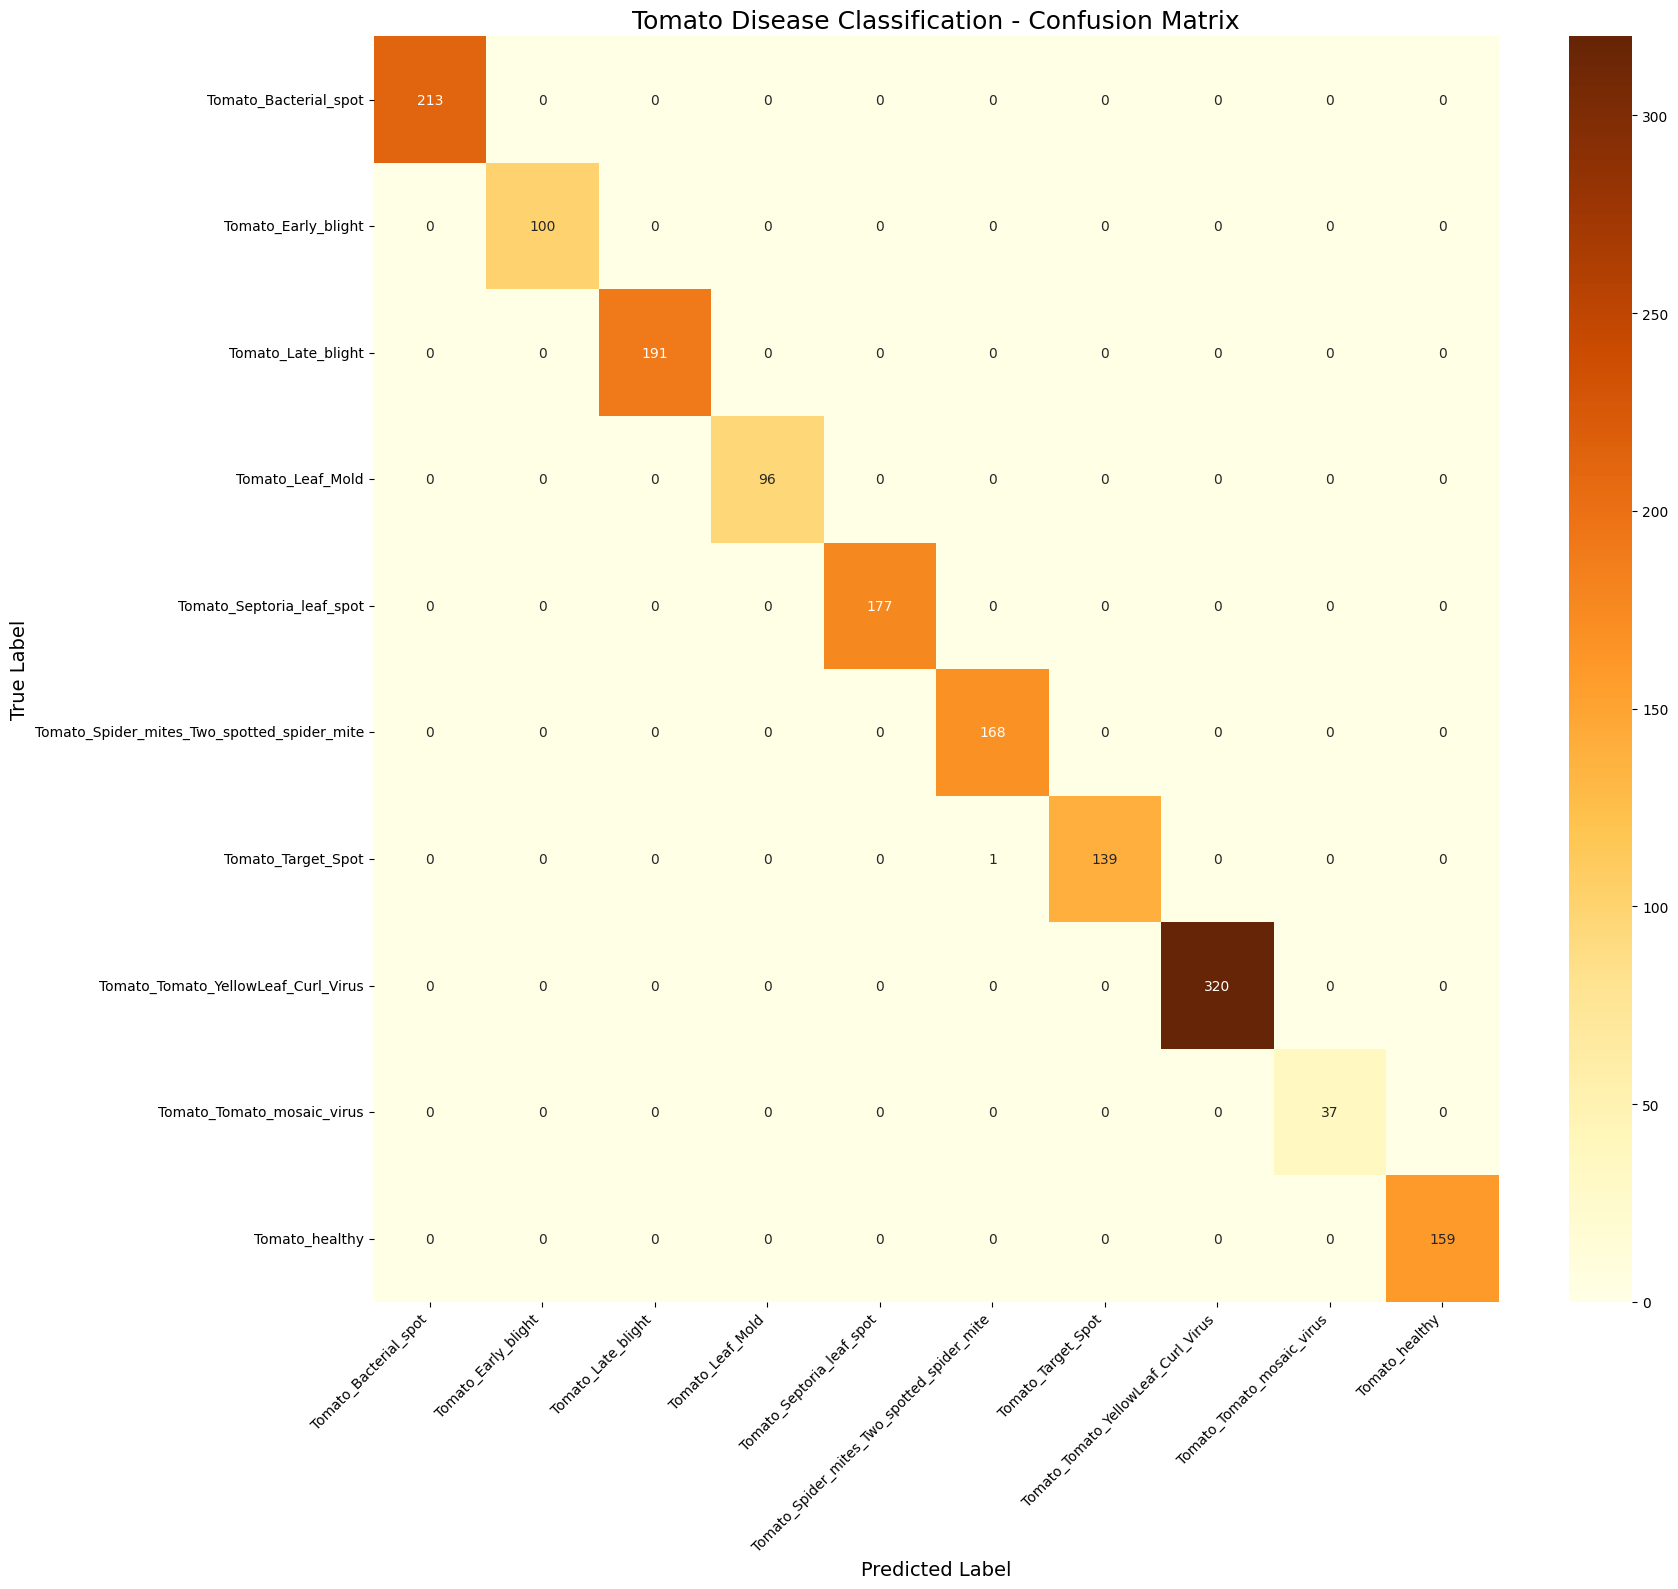

In [38]:
plt.figure(figsize=(18, 16))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrBr",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Tomato Disease Classification - Confusion Matrix", fontsize=18)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [35]:
import json

class_names = test_dataset.classes

CLASS_NAMES_PATH = (
    "/content/drive/MyDrive/"
    "ml-service/tomato_class_names.json"
)

with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(class_names, f, indent=4)

print("Class names saved!")
print(CLASS_NAMES_PATH)

Class names saved!
/content/drive/MyDrive/ml-service/tomato_class_names.json


In [39]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.models import efficientnet_b0

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [40]:
import os

print(os.listdir("/content"))

['.config', 'tomato', 'drive', 'sample_data']


In [41]:
test_dir = "/content/tomato/test"

print(os.listdir(test_dir))

['Tomato_Septoria_leaf_spot', 'Tomato_Bacterial_spot', 'Tomato_Target_Spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato_Tomato_mosaic_virus', 'Tomato_healthy', 'Tomato_Tomato_YellowLeaf_Curl_Virus', 'Tomato_Late_blight', 'Tomato_Leaf_Mold']


In [42]:
!find /content -maxdepth 3 -type d | head -50

/content
/content/.config
/content/.config/configurations
/content/.config/logs
/content/.config/logs/2026.09.04
/content/tomato
/content/tomato/train
/content/tomato/train/Tomato_Septoria_leaf_spot
/content/tomato/train/Tomato_Bacterial_spot
/content/tomato/train/Tomato_Target_Spot
/content/tomato/train/Tomato_Spider_mites_Two_spotted_spider_mite
/content/tomato/train/Tomato_Early_blight
/content/tomato/train/Tomato_Tomato_mosaic_virus
/content/tomato/train/Tomato_healthy
/content/tomato/train/Tomato_Tomato_YellowLeaf_Curl_Virus
/content/tomato/train/Tomato_Late_blight
/content/tomato/train/Tomato_Leaf_Mold
/content/tomato/test
/content/tomato/test/Tomato_Septoria_leaf_spot
/content/tomato/test/Tomato_Bacterial_spot
/content/tomato/test/Tomato_Target_Spot
/content/tomato/test/Tomato_Spider_mites_Two_spotted_spider_mite
/content/tomato/test/Tomato_Early_blight
/content/tomato/test/Tomato_Tomato_mosaic_virus
/content/tomato/test/Tomato_healthy
/content/tomato/test/Tomato_Tomato_YellowLe

In [43]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

class_names = test_dataset.classes

print("Number of classes:", len(class_names))
print("Classes:")

for i, name in enumerate(class_names):
    print(i, name)

print("\nTotal test images:", len(test_dataset))

Number of classes: 10
Classes:
0 Tomato_Bacterial_spot
1 Tomato_Early_blight
2 Tomato_Late_blight
3 Tomato_Leaf_Mold
4 Tomato_Septoria_leaf_spot
5 Tomato_Spider_mites_Two_spotted_spider_mite
6 Tomato_Target_Spot
7 Tomato_Tomato_YellowLeaf_Curl_Virus
8 Tomato_Tomato_mosaic_virus
9 Tomato_healthy

Total test images: 1601


In [45]:
!find /content -type f \( -name "*.pth" -o -name "*.pt" \)

/content/best_tomato_disease_model.pth
/content/drive/MyDrive/ml-service/best_tomato_disease_model.pth


In [46]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.models import efficientnet_b0

# Paths
test_dir = "/content/tomato/test"
model_path = "/content/best_tomato_disease_model.pth"

# Same preprocessing used for EfficientNet
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load test dataset
test_dataset = datasets.ImageFolder(
    test_dir,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

class_names = test_dataset.classes

print("Number of classes:", len(class_names))
print("Classes:")

for i, name in enumerate(class_names):
    print(f"{i}: {name}")

print("\nTotal test images:", len(test_dataset))

Number of classes: 10
Classes:
0: Tomato_Bacterial_spot
1: Tomato_Early_blight
2: Tomato_Late_blight
3: Tomato_Leaf_Mold
4: Tomato_Septoria_leaf_spot
5: Tomato_Spider_mites_Two_spotted_spider_mite
6: Tomato_Target_Spot
7: Tomato_Tomato_YellowLeaf_Curl_Virus
8: Tomato_Tomato_mosaic_virus
9: Tomato_healthy

Total test images: 1601


In [47]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# Create EfficientNet-B0
model = efficientnet_b0(weights=None)

# Change final layer for 10 tomato disease classes
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    len(class_names)
)

# Load trained weights
checkpoint = torch.load(
    model_path,
    map_location=device
)

# Handle different possible saving formats
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print("Model loaded successfully!")

Using device: cuda
Model loaded successfully!


In [48]:
import numpy as np

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("Testing completed!")
print("Total images tested:", len(all_labels))

Testing completed!
Total images tested: 1601


In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 99.94%


In [50]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4
)

print(report)

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot     1.0000    1.0000    1.0000       213
                        Tomato_Early_blight     1.0000    1.0000    1.0000       100
                         Tomato_Late_blight     1.0000    1.0000    1.0000       191
                           Tomato_Leaf_Mold     1.0000    1.0000    1.0000        96
                  Tomato_Septoria_leaf_spot     1.0000    1.0000    1.0000       177
Tomato_Spider_mites_Two_spotted_spider_mite     0.9941    1.0000    0.9970       168
                         Tomato_Target_Spot     1.0000    0.9929    0.9964       140
        Tomato_Tomato_YellowLeaf_Curl_Virus     1.0000    1.0000    1.0000       320
                 Tomato_Tomato_mosaic_virus     1.0000    1.0000    1.0000        37
                             Tomato_healthy     1.0000    1.0000    1.0000       159

                                   accuracy                    

In [51]:
from google.colab import files

uploaded = files.upload()

Saving images.jpg to images (1).jpg


In [52]:
from PIL import Image

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")

# Preprocess
input_tensor = test_transform(image)

# Add batch dimension
input_tensor = input_tensor.unsqueeze(0)

# Move to GPU
input_tensor = input_tensor.to(device)

# Prediction
with torch.no_grad():

    output = model(input_tensor)

    probabilities = torch.softmax(
        output,
        dim=1
    )

    predicted_index = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = probabilities[
        0, predicted_index
    ].item()

predicted_class = class_names[predicted_index]

print("======================================")
print("       TOMATO DISEASE PREDICTION")
print("======================================")
print("Predicted Disease :", predicted_class)
print(f"Confidence        : {confidence * 100:.2f}%")

       TOMATO DISEASE PREDICTION
Predicted Disease : Tomato_Early_blight
Confidence        : 55.40%


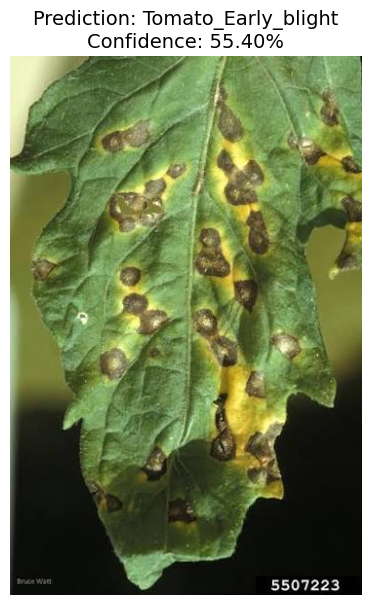

In [53]:
plt.figure(figsize=(7, 7))

plt.imshow(image)
plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%",
    fontsize=14
)

plt.show()

What you say to the reviewer

When you reach this step:

“Now I am testing the trained EfficientNet-B0 model on the independent test dataset. The test images were not used during model training. We calculate accuracy, precision, recall and F1-score to evaluate the classification performance.”

Then show the metrics.

After that, upload a new image and say:

“Now I am giving the model a completely new tomato leaf image. The image goes through the same preprocessing pipeline and is passed to the trained EfficientNet-B0 model. The model predicts the disease class based on the learned visual features.”

Then:

“For this image, the model predicts [disease name] with [confidence]% confidence.”

⚠️ One important check before you present

You have:

/content/best_tomato_disease_model.pth

and also:

/content/drive/MyDrive/ml-service/best_tomato_disease_model.pth

Use the same checkpoint that produced your current confusion matrix. Otherwise, your new test result may differ from the 99.94% result you showed me.

In [54]:
top_probs, top_indices = torch.topk(
    probabilities[0],
    3
)

print("======================================")
print("       TOP 3 PREDICTIONS")
print("======================================")

for rank, (prob, idx) in enumerate(
    zip(top_probs, top_indices), 1
):
    print(
        f"{rank}. {class_names[idx.item()]} "
        f"-> {prob.item() * 100:.2f}%"
    )

       TOP 3 PREDICTIONS
1. Tomato_Early_blight -> 55.40%
2. Tomato_Late_blight -> 44.37%
3. Tomato_Bacterial_spot -> 0.14%
